In [1]:
import pandas as pd
import os.path as op
import platform
import os
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin

In [2]:
if platform.system() == "Windows":
    wanted_dir = "/data/sourcedata/behavior/modified_files"
else:
    wanted_dir = "/Volumes/SDrive/data/sourcedata/behavior/modified_files"

files = [os.path.join(root, name) for root, dirs, files in os.walk(wanted_dir) for name in files if name.endswith('savedValues.csv')and not name.startswith("._")]

files.remove(files[7])
files.remove(files[11])
files.remove(files[13])
files.remove(files[38])
len(files)


58

In [4]:
subjects =[]
for i in range(len(files)):
    subjects.append(int(files[i][-18:-16]))
    
data_folder = '/Volumes/SDrive/data/'
subjects, len(subjects)

([1,
  2,
  3,
  4,
  5,
  6,
  7,
  9,
  10,
  11,
  12,
  14,
  15,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64],
 58)

In [5]:
df = []

for subject in subjects:
    d = pd.read_csv(op.join(data_folder, 'sourcedata', 'behavior', 'modified_files', f'modified_participant{subject:02d}_savedValues.csv'))

    df.append(d.set_index(['runNumber', 'trialNumber']))

df = pd.concat(df, keys=subjects, names=['subject'])

In [6]:
spes = []

for subject in subjects:
    # print(subject)

    try:
        spe = loadmat(f'/Volumes/SDrive/data/fittedParameters/sub-{subject:02d}/spe.mat')['spe']

        spe = pd.DataFrame(spe, columns=pd.Index(np.arange(1, 61), name='trialNumber'), index=pd.Index(np.arange(1, 7), name='runNumber'))

        spe = spe.stack().to_frame('spe')

        spes.append(spe)

    except Exception as e:
        subjects.pop(subjects.index(subject))
        print(f'There was a problem with subject {subject}:\n{e}')

spes = pd.concat(spes, keys=subjects, names=['subject'])
spes

spe
subject runNumber trialNumber          
1       1         1            2.197225
                  2            2.302585
                  3            2.397895
                  4            2.484907
                  5            2.564949
...                                 ...
64      6         56           3.060271
                  57           1.871802
                  58           2.397895
                  59           2.258782
                  60           2.273598

[20880 rows x 1 columns]

In [7]:
df = df.join(spes)

In [8]:
list(df.columns)

['visualSet',
 'audioPair_1',
 'audioPair_2',
 'audioPair_3',
 'tactilePair_1',
 'tactilePair_2',
 'tactilePair_3',
 'visual',
 'audio',
 'tactile',
 'combinationConditionalProbability',
 'correctResponse',
 'chosenKey',
 'accurate',
 'reward',
 'runStartTime',
 'trialStartTime',
 'stimulusOnsetTime',
 'stimulusOffsetTime',
 'responsePressTime',
 'responseTime',
 'responseTimeOver',
 'feedbackOnsetTime',
 'responseTimeThreshold',
 'totalAccuracy',
 'totalErrorRate',
 'accurateIndex',
 'inaccurateIndex',
 'feedbackAccuracy',
 'feedbackOffsetTime',
 'action',
 'stimulusPair',
 'spe']

0.06448031642506036


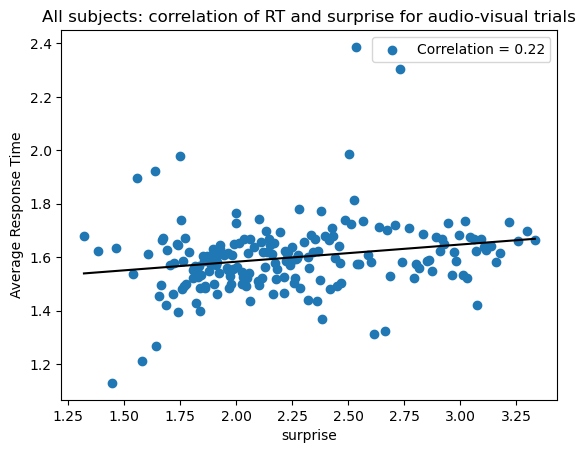

In [9]:

audio_df = df.dropna(subset=['audio'])


avg_response_time = audio_df.groupby('spe')['responseTime'].mean()

plt.scatter(avg_response_time.index, avg_response_time.values, label=f'Correlation = {np.round(np.corrcoef(avg_response_time.index, avg_response_time.values)[0,1], 2)}')

plt.legend()

m, b = np.polyfit(avg_response_time.index, avg_response_time.values, 1)
plt.plot(avg_response_time.index, m*avg_response_time.index+b, c = "k")


print(m)

plt.xlabel('surprise')
plt.ylabel('Average Response Time')
plt.title("All subjects: correlation of RT and surprise for audio-visual trials")
plt.show()

In [10]:
pingouin.rm_corr(audio_df.reset_index(), x='spe', y='responseTime', subject='subject')

,r,dof,pval,CI95%,power
rm_corr,0.079453,10303,6.619029e-16,"[0.06, 0.1]",1.0


0.02815367410674916


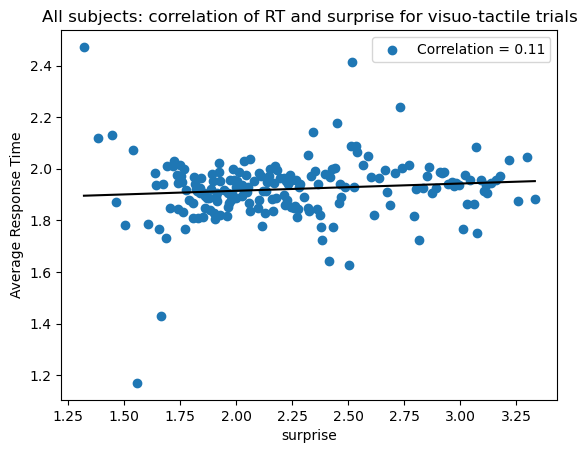

In [11]:

tactile_df = df.dropna(subset=['tactile'])


avg_response_time = tactile_df.groupby('spe')['responseTime'].mean()

plt.scatter(avg_response_time.index, avg_response_time.values, label=f'Correlation = {np.round(np.corrcoef(avg_response_time.index, avg_response_time.values)[0,1], 2)}')

plt.legend()

m, b = np.polyfit(avg_response_time.index, avg_response_time.values, 1)
plt.plot(avg_response_time.index, m*avg_response_time.index+b, c = "k")

print(m) 

plt.xlabel('surprise')
plt.ylabel('Average Response Time')
plt.title("All subjects: correlation of RT and surprise for visuo-tactile trials")
plt.show()

In [12]:
pingouin.rm_corr(tactile_df.reset_index(), x='spe', y='responseTime', subject='subject')

,r,dof,pval,CI95%,power
rm_corr,0.038062,10264,0.000115,"[0.02, 0.06]",0.971154


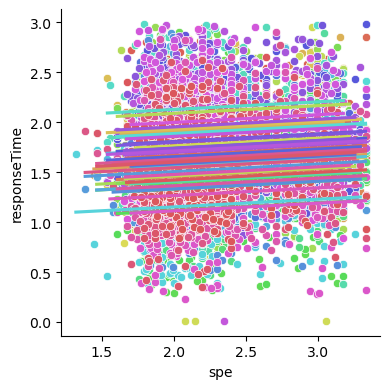

In [13]:
pingouin.plot_rm_corr(audio_df.reset_index(), x='spe', y='responseTime', subject='subject')

Text(-11.055555555555555, 0.5, 'r')

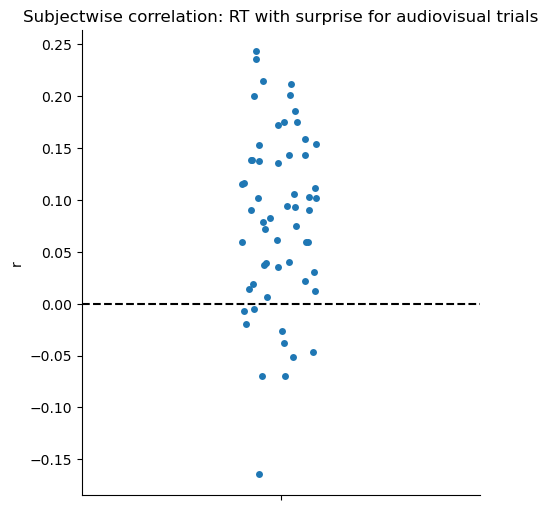

In [14]:

r_a = audio_df.groupby('subject').apply(lambda d: pingouin.corr(d['spe'], d['responseTime']))

sns.catplot(r_a, y='r')
plt.axhline(0.0, c='k' ,ls='--')
plt.title("Subjectwise correlation: RT with surprise for audiovisual trials")
plt.ylabel("r")

Text(0.5, 1.0, 'Subjectwise correlation: RT with surprise for visuotactile trials')

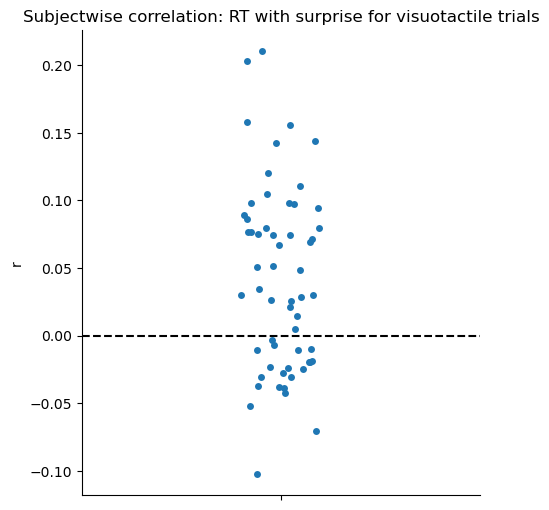

In [15]:

r_t = tactile_df.groupby('subject').apply(lambda d: pingouin.corr(d['spe'], d['responseTime']))

sns.catplot(r_t, y='r')
plt.axhline(0.0, c='k' ,ls='--')
plt.title("Subjectwise correlation: RT with surprise for visuotactile trials")

In [16]:
df['audio_indicator'] = df['audio'].notna().astype(int)
df

visualSet  audioPair_1  audioPair_2  \
subject runNumber trialNumber                                        
1       1         1                    0            1            0   
                  2                    0            1            0   
                  3                    0            1            0   
                  4                    0            1            0   
                  5                    0            1            0   
...                                  ...          ...          ...   
64      6         56                   5            2            0   
                  57                   5            2            0   
                  58                   5            2            0   
                  59                   5            2            0   
                  60                   5            2            0   

                               audioPair_3  tactilePair_1  tactilePair_2  \
subject runNumber trialNumber                                              
1       1         1                      2              0              1   
                  2                      2              0              1   
                  3                      2              0              1   
                  4                      2              0              1   
                  5                      2              0              1   
...                                    ...            ...            ...   
64      6         56                     1              1              2   
                  57                     1              1              2   
                  58                     1              1              2   
                  59                     1              1              2   
                  60                     1              1              2   

                               tactilePair_3  visual  audio  tactile  ...  \
subject runNumber trialNumber                                         ...   
1       1         1                        2       0    NaN      2.0  ...   
                  2                        2       1    NaN      1.0  ...   
                  3                        2       2    NaN      2.0  ...   
                  4                        2       0    NaN      0.0  ...   
                  5                        2       2    NaN      1.0  ...   
...                                      ...     ...    ...      ...  ...   
64      6         56                       0       0    1.0      NaN  ...   
                  57                       0       1    0.0      NaN  ...   
                  58                       0       2    2.0      NaN  ...   
                  59                       0       1    1.0      NaN  ...   
                  60                       0       2    2.0      NaN  ...   

                               totalAccuracy  totalErrorRate accurateIndex  \
subject runNumber trialNumber                                                
1       1         1                 0.000000        1.000000             1   
                  2                 0.000000        1.000000             1   
                  3                 0.333333        0.666667             1   
                  4                 0.250000        0.750000             2   
                  5                 0.200000        0.800000             2   
...                                      ...             ...           ...   
64      6         56                0.892857        0.107143            50   
                  57                0.894737        0.105263            51   
                  58                0.896552        0.103448            52   
                  59                0.898305        0.101695            53   
                  60                0.900000        0.100000            54   

                               inaccurateIndex  feedbackAccuracy  \
subject runNumber trialNumber                 

In [17]:
df['responseTime'].isnull().sum()

195

In [18]:
data=df.dropna(subset=['responseTime'])

df.loc[:,"audio_indicator"] = df.loc[:,"audio_indicator"] - df.loc[:,"audio_indicator"].mean()

In [19]:
import statsmodels.formula.api as sm

# df = df.reset_index()

# Create the formula for the mixed-effects model
formula = 'responseTime ~ spe + audio_indicator + spe:audio_indicator'

# Fit the mixed-effects model using the MixedLM class
model = sm.mixedlm(formula, data=df.dropna(subset=['responseTime']).reset_index(), groups='subject', re_formula='~audio_indicator')

model_fit = model.fit(method='bfgs')

# Print the summary of the model
print(model_fit.summary())

                  Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      responseTime
No. Observations:      20685        Method:                  REML        
No. Groups:            58           Scale:                   0.1362      
Min. group size:       343          Log-Likelihood:          -8967.1883  
Max. group size:       360          Converged:               Yes         
Mean group size:       356.6                                             
-------------------------------------------------------------------------
                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------
Intercept                      1.650    0.032  52.236 0.000  1.588  1.712
spe                            0.056    0.007   8.507 0.000  0.043  0.069
audio_indicator               -0.401    0.037 -10.877 0.000 -0.473 -0.329
spe:audio_indicator            0.042    0.013   3.167 0.

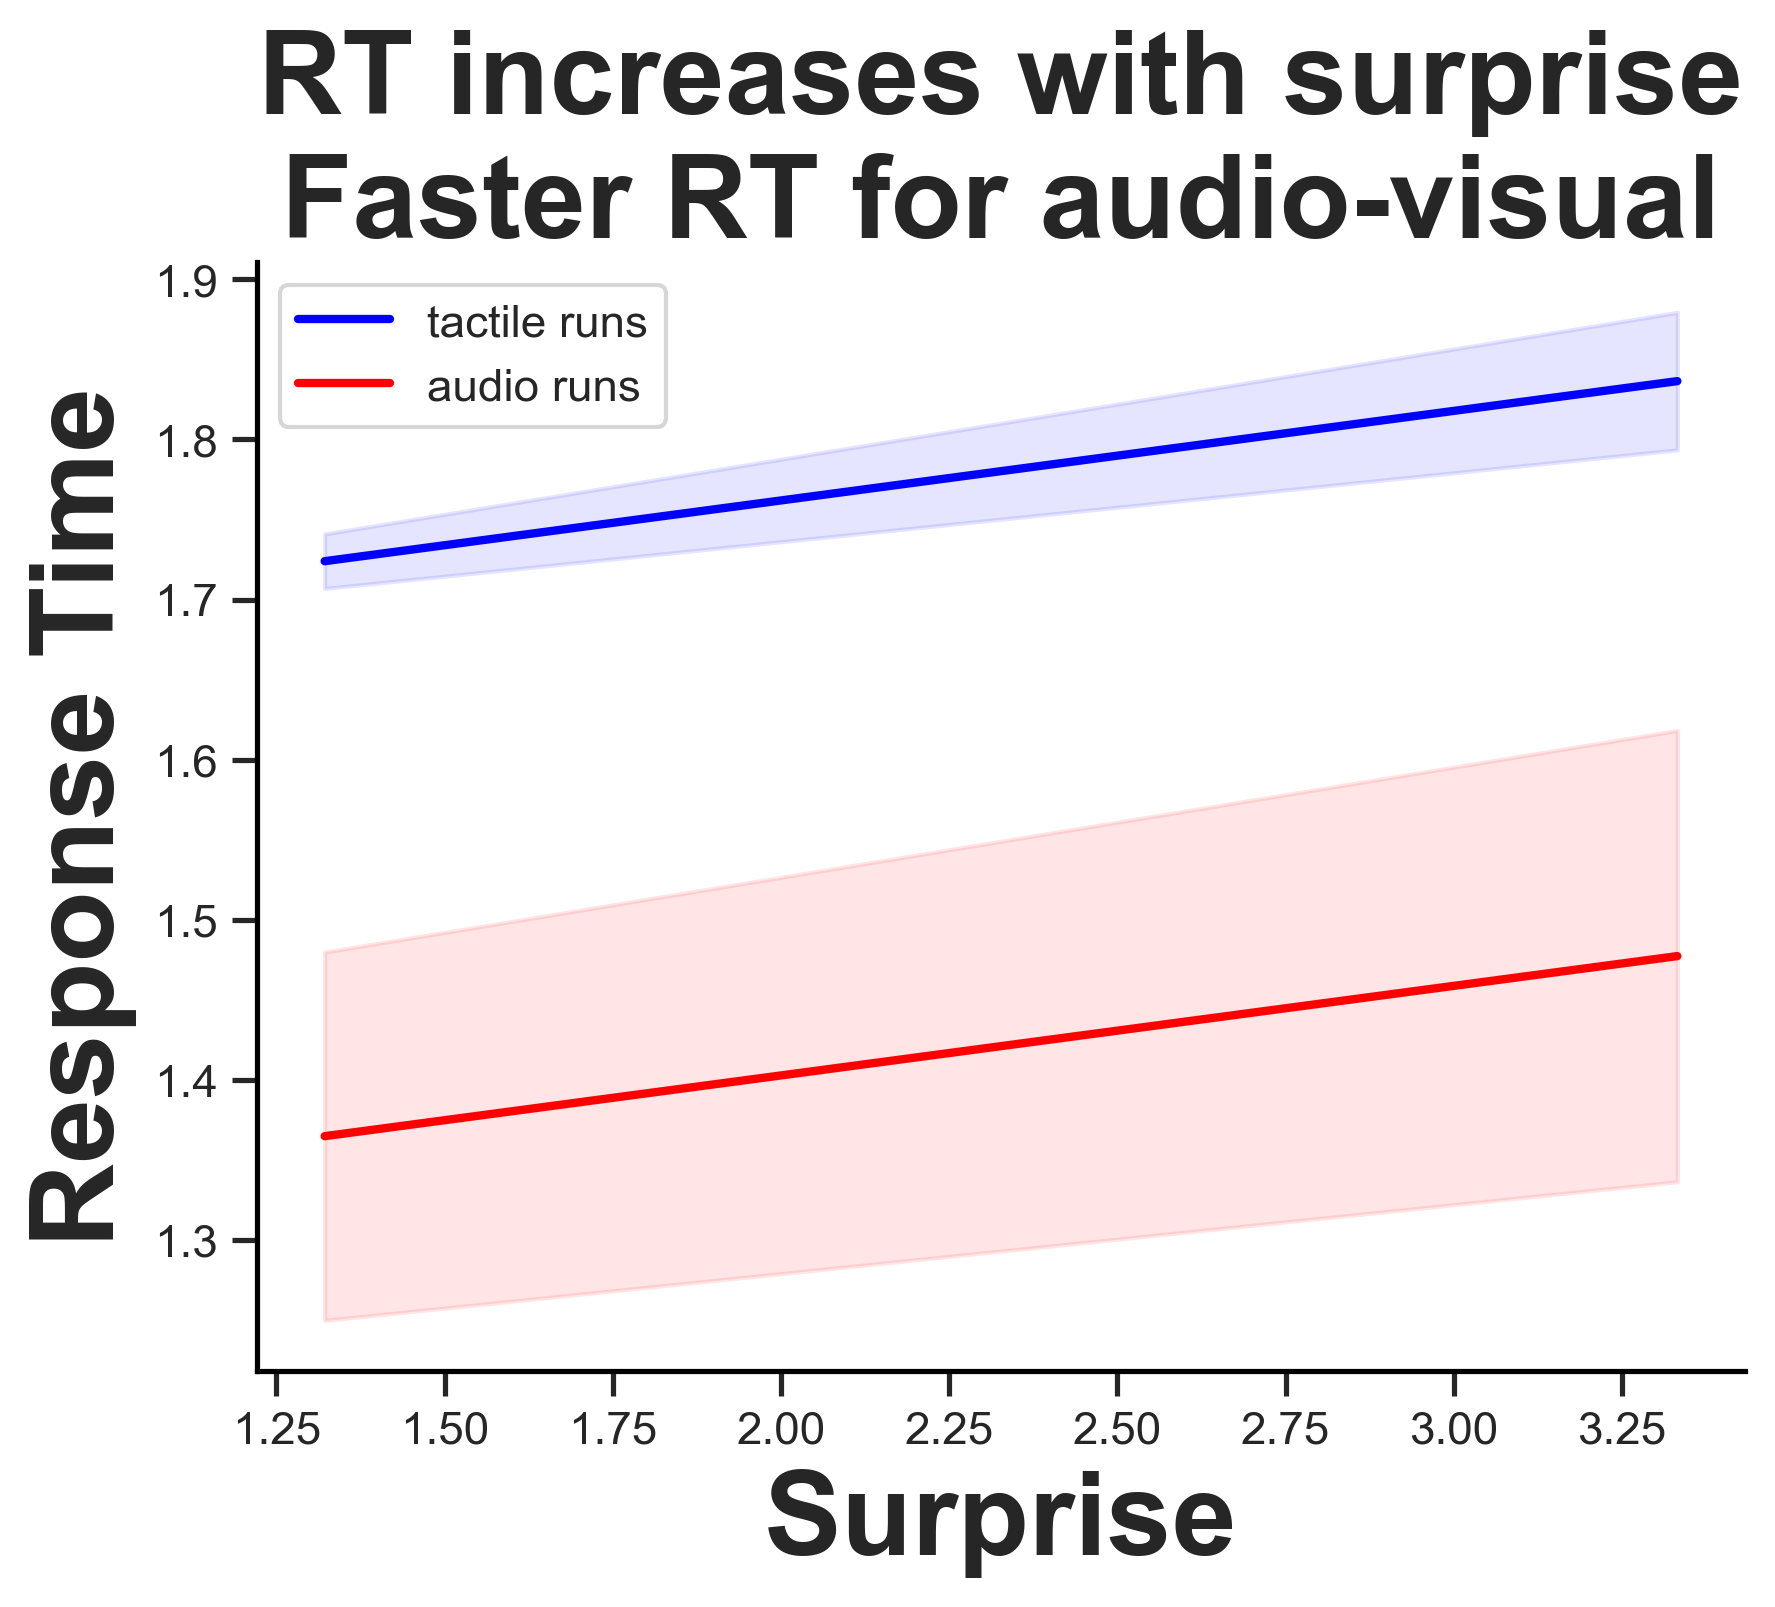

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a white background for the entire figure
plt.rcParams['axes.facecolor'] = 'white'

# Set a high DPI for high-quality images
plt.rcParams['figure.dpi'] = 300

# Generate data for line plots
x0 = np.linspace(min(df[df['audio_indicator'] == -0.5]['spe']), max(df[df['audio_indicator'] == -0.5]['spe']), 100)
y0 = model_fit.params['spe'] * x0 + model_fit.params['Intercept']
ci0 = model_fit.conf_int().loc['spe']
y0_upper = ci0[1] * x0 + model_fit.params['Intercept']
y0_lower = ci0[0] * x0 + model_fit.params['Intercept']

x1 = np.linspace(min(df[df['audio_indicator'] == 0.5]['spe']), max(df[df['audio_indicator'] == 0.5]['spe']), 100)
y1 = (model_fit.params['spe'] * x1 + model_fit.params['audio_indicator']
      + model_fit.params['spe:audio_indicator'] + model_fit.params['Intercept'])
ci1 = model_fit.conf_int().loc[['spe', 'audio_indicator', 'spe:audio_indicator']]
y1_upper = (ci1.loc['spe', 1] * x1 + ci1.loc['audio_indicator', 1]
            + ci1.loc['spe:audio_indicator', 1] + model_fit.params['Intercept'])
y1_lower = (ci1.loc['spe', 0] * x1 + ci1.loc['audio_indicator', 0]
            + ci1.loc['spe:audio_indicator', 0] + model_fit.params['Intercept'])

# Create figure and axis objects
fig, ax = plt.subplots()

# Plot lines and confidence intervals for correlations between spe and responseTime
ax.plot(x0, y0, color='blue', alpha=1., linewidth=2, label='tactile runs')
ax.fill_between(x0, y0_upper, y0_lower, color='blue', alpha=.1)
ax.plot(x1, y1, color='red', alpha=1., linewidth=2, label='audio runs')
ax.fill_between(x1, y1_upper, y1_lower, color='red', alpha=.1)

# Overlay scatter plots for two audio_indicator values (uncomment if needed)
# ax.scatter(df[df['audio_indicator'] == 0]['spe'], df[df['audio_indicator'] == 0]['responseTime'], color='blue', alpha=0.04, s=1)
# ax.scatter(df[df['audio_indicator'] == 1]['spe'], df[df['audio_indicator'] == 1]['responseTime'], color='red', alpha=0.04, s=1)

# Set axis labels and legend
ax.set_xlabel('Surprise', fontsize=28, weight='bold')
ax.set_ylabel('Response Time', fontsize=28, weight='bold')
plt.title("RT increases with surprise\nFaster RT for audio-visual", fontsize=28, weight='bold')
ax.legend()

# Remove grid lines
ax.grid(False)

# Show only axis lines and axis ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# Save the figure with a white background
plt.savefig("publication_worthy_figure.png", dpi=300, bbox_inches="tight")

# Show plot
plt.show()
